# This program is used to simulate complacency effect on the state of OH

In [2]:
# Import all the libraries
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import re
import numpy as np
from pprint import pprint
from sklearn.linear_model import LinearRegression
import numpy as np

In [4]:
file_path = (r"..\..\final_data\OH.csv")

OH_data = pd.read_csv(file_path)

In [3]:
OH_data['primary_total_votes'] = OH_data['dem_primary_total'] + OH_data['rep_primary_total']
OH_data['general_total_votes'] = OH_data['dem_general_total'] + OH_data['rep_general_total']

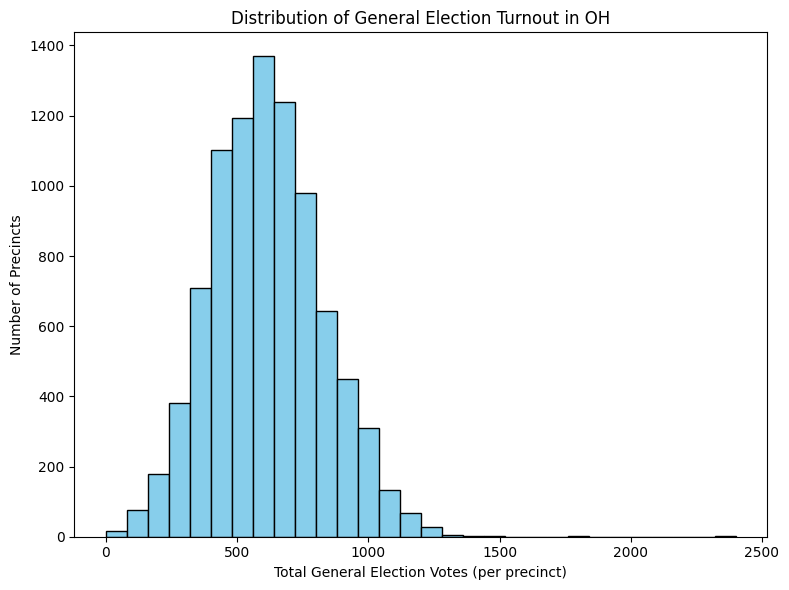

In [4]:
#Distribution of total general votes (Dem + Rep) per precinct

plt.figure(figsize=(8, 6))
plt.hist(OH_data['general_total_votes'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Total General Election Votes (per precinct)')
plt.ylabel('Number of Precincts')
plt.title('Distribution of General Election Turnout in OH')
plt.tight_layout()

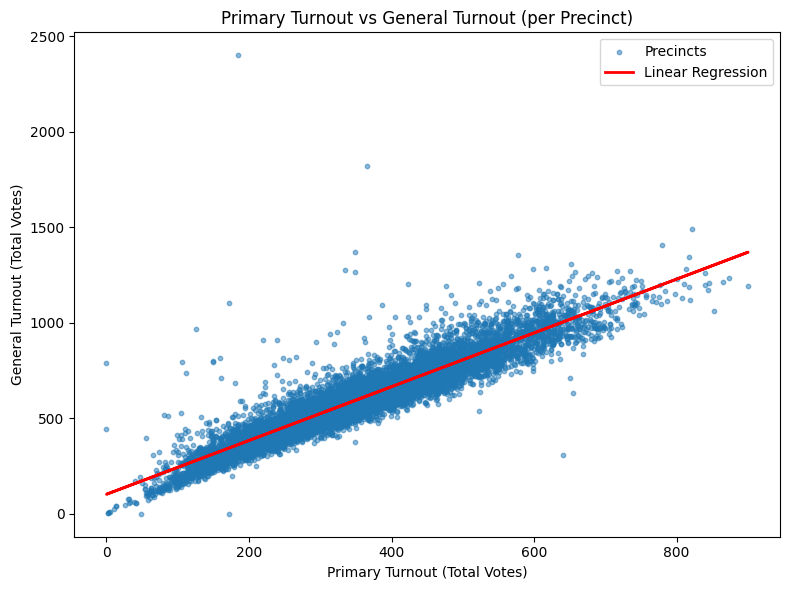

In [5]:
# Prepare X and y for regression
X = OH_data['primary_total_votes'].values.reshape(-1, 1)
y = OH_data['general_total_votes'].values

# Fit linear regression
reg = LinearRegression()
reg.fit(X, y)

# Predict values for the regression line
y_pred = reg.predict(X)

# Plot: Primary turnout vs General turnout with regression line
plt.figure(figsize=(8, 6))
plt.scatter(OH_data['primary_total_votes'], OH_data['general_total_votes'], alpha=0.5, s=10, label='Precincts')
plt.plot(OH_data['primary_total_votes'], y_pred, color='red', linewidth=2, label='Linear Regression')
plt.xlabel('Primary Turnout (Total Votes)')
plt.ylabel('General Turnout (Total Votes)')
plt.title('Primary Turnout vs General Turnout (per Precinct)')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# After fitting the model
beta_0 = reg.intercept_
beta_1 = reg.coef_[0]

print(f"Intercept (β₀): {beta_0:.4f}")
print(f"Slope (β₁): {beta_1:.4f}")

Intercept (β₀): 102.2300
Slope (β₁): 1.4076


In [5]:
# Estimate precinct size based geometric approach
# Calculate probability of voting for each party in the general election
OH_data["general_turnout"] = OH_data["rep_general_total"] + OH_data["dem_general_total"]
OH_data["primary_turnout"] = OH_data["rep_primary_total"] + OH_data["dem_primary_total"]
general_turnoutprob = 0.71 # General turnout prob for Rep
primary_turnoutprob= 0.42 # Primary turnout prob for Rep
m = general_turnoutprob / primary_turnoutprob
OH_data["general_turnout_est"] = (OH_data['primary_turnout'] + m * OH_data['general_turnout']) / (1 + m **2)
OH_data["precinct_size"] = OH_data["general_turnout_est"] / primary_turnoutprob 

In [6]:
# Calculate the margin of each precinct margin = abs(rep_primary_total - dem_primary_total) / (rep_primary_total + dem_primary_total)
OH_data['primary_margin'] = np.abs(OH_data['rep_primary_total'] - OH_data['dem_primary_total']) / (OH_data['rep_primary_total'] + OH_data['dem_primary_total'])


In [7]:
# Calculate estimated number of Democratic voters per precinct
OH_data['dem_voters'] = (OH_data['dem_primary_total'] / (OH_data['dem_primary_total'] + OH_data['rep_primary_total'])) * OH_data['precinct_size']
OH_data['rep_voters'] = (OH_data['rep_primary_total'] / (OH_data['dem_primary_total'] + OH_data['rep_primary_total'])) * OH_data['precinct_size']

In [10]:
# Determine the winner based on primary totals
OH_data['primary_winner'] = np.where(
    OH_data['rep_primary_total'] > OH_data['dem_primary_total'], 'rep', 'dem'
)  

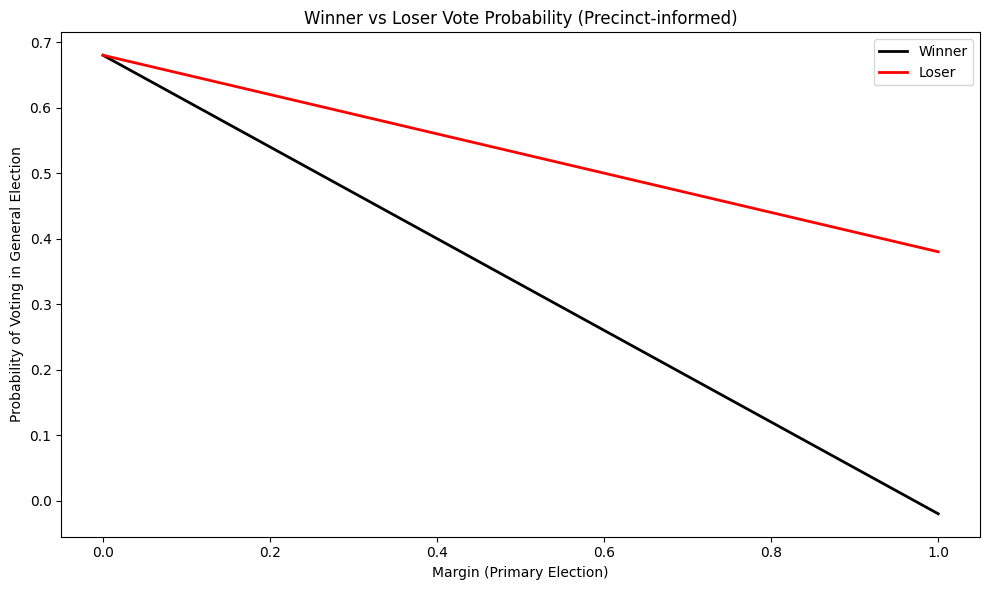

In [11]:
# Plotting vote chance
# Define x range: margin from 0 (tie) to 1 (blowout)
margins = np.linspace(0, 1, 200)

# Parameters
b = 0.68          # max vote probability at tie
m_w = 0.7      # steeper slope for winner
m_l = 0.3        # flatter slope for loser

# Calculate probabilities
prob_winner = b - m_w * margins
prob_loser = b - m_l * margins

# Plot
plt.figure(figsize=(10, 6))
plt.plot(margins, prob_winner, label="Winner", color='black', linewidth=2)
plt.plot(margins, prob_loser, label="Loser", color='red', linewidth=2)

# Labels and titles
plt.title("Winner vs Loser Vote Probability (Precinct-informed)")
plt.xlabel("Margin (Primary Election)")
plt.ylabel("Probability of Voting in General Election")
plt.legend()
plt.tight_layout()

In [13]:
# 1. Estimate number of non-primary voters for each party
OH_data['predicted_dem_gen'] = np.where(
    OH_data['primary_winner'] == 'dem',
    (b - OH_data['primary_margin'] * m_w)* OH_data['dem_voters'],  
    (b - OH_data['primary_margin'] * m_l)* OH_data['dem_voters']
)

# For Republicans
OH_data['predicted_rep_gen'] = np.where(
    OH_data['primary_winner'] == 'rep',
    (b - OH_data['primary_margin'] * m_w)* OH_data['rep_voters'],  
    (b - OH_data['primary_margin'] * m_l)* OH_data['rep_voters']
)

In [14]:
# Compare to actual general vote shares
OH_data['actual_general_rep_share'] = OH_data['rep_general_total'] / (
    OH_data['rep_general_total'] + OH_data['dem_general_total']
)
OH_data['predicted_rep_share'] = OH_data['predicted_rep_gen'] / (
    OH_data['predicted_rep_gen'] + OH_data['predicted_dem_gen']
)
OH_data['primary_rep_voteshare'] = OH_data['rep_primary_total'] / (
    OH_data['rep_primary_total'] + OH_data['dem_primary_total']
)



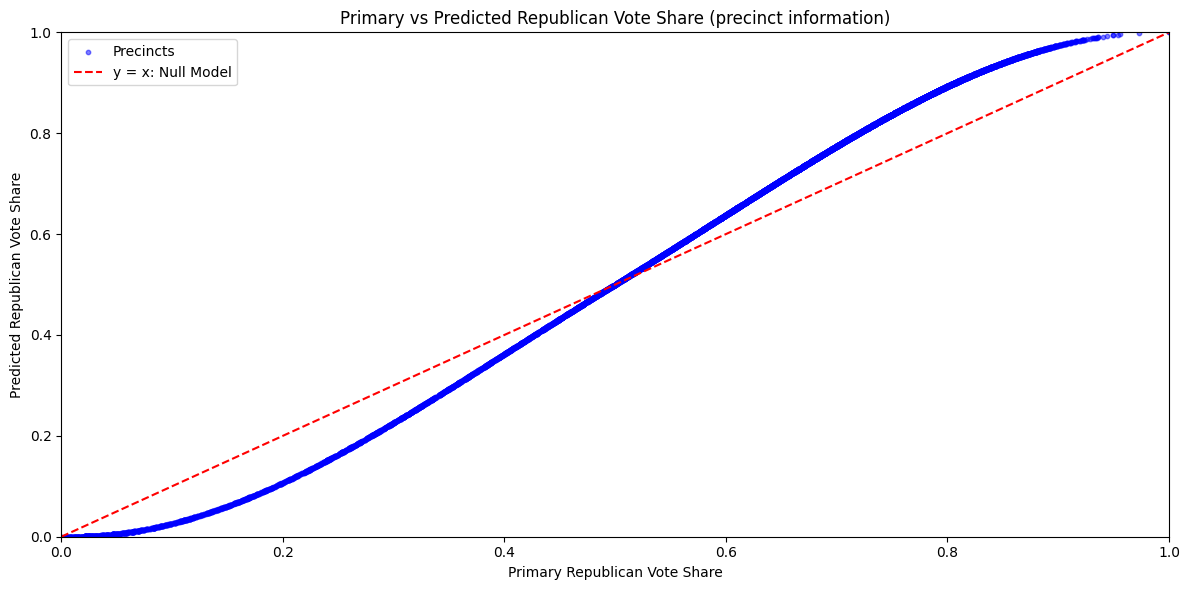

In [15]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=OH_data['primary_rep_voteshare'], 
    y=OH_data['predicted_rep_share'], 
    color='blue', label='Precincts', alpha=0.5, s=10
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Null Model')
plt.title('Primary vs Predicted Republican Vote Share (precinct information)')
plt.xlabel('Primary Republican Vote Share')
plt.ylabel('Predicted Republican Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


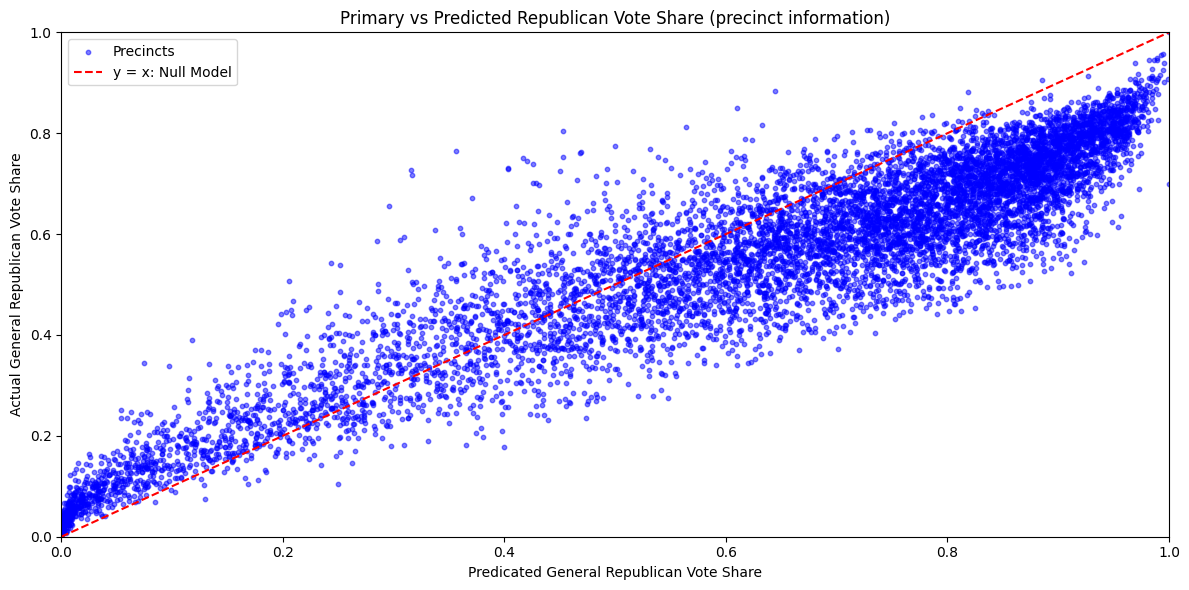

In [16]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=OH_data['predicted_rep_share'], 
    y=OH_data['actual_general_rep_share'], 
    color='blue', label='Precincts', alpha=0.5, s=10
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Null Model')
plt.title('Primary vs Predicted Republican Vote Share (precinct information)')
plt.xlabel('Predicated General Republican Vote Share')
plt.ylabel('Actual General Republican Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## State - level Information

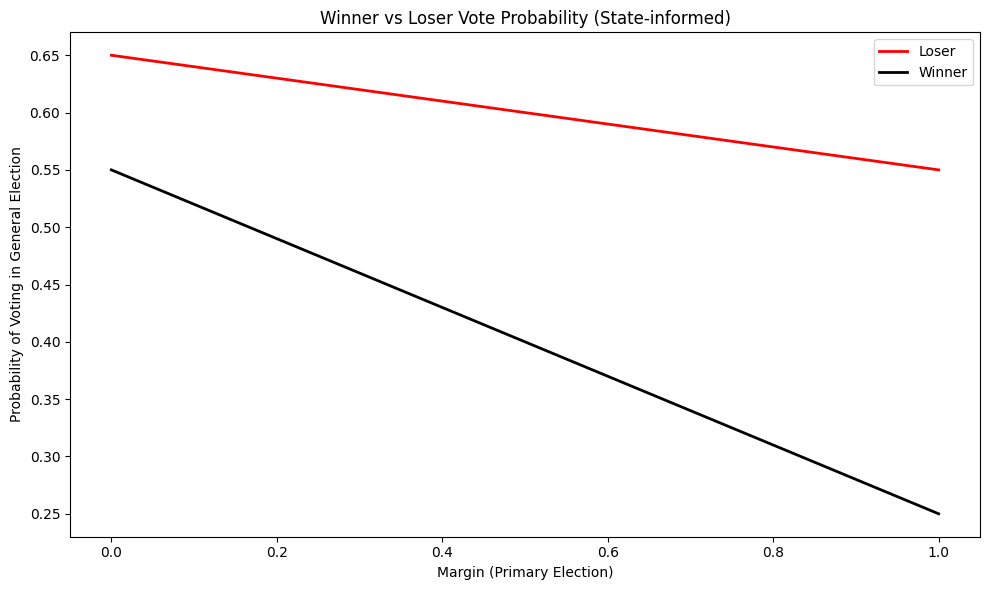

In [29]:
# Plotting vote chance
# Define x range: margin from 0 (tie) to 1 (blowout)
margins = np.linspace(0, 1, 200)

# Parameters
b_w = 0.55          # max vote probability at tie
b_l = 0.65
m_w = 0.3      # steeper slope for winner
m_l = 0.1        # flatter slope for loser

# Calculate probabilities
prob_winner = b_w - m_w * margins
prob_loser = b_l - m_l * margins

# Plot
plt.figure(figsize=(10, 6))
plt.plot(margins, prob_loser, label="Loser", color='red', linewidth=2)
plt.plot(margins, prob_winner, label="Winner", color='black', linewidth=2)

# Labels and titles
plt.title("Winner vs Loser Vote Probability (State-informed)")
plt.xlabel("Margin (Primary Election)")
plt.ylabel("Probability of Voting in General Election")
plt.legend()
plt.tight_layout()

In [18]:
# Determine the winner based on primary totals
# OH_data['state_primary_winner'] = np.where(
#     OH_data['rep_primary_total'].sum() > OH_data['dem_primary_total'].sum(), 'rep', 'dem'
# )  
OH_data['state_primary_winner'] = np.where(
    OH_data['rep_primary_total'].sum() > OH_data['dem_primary_total'].sum(), 'rep', 'dem'
)  

In [19]:
OH_data

,Unnamed: 0,...1,precinct,gen_rep_TRUMP,gen_dem_CLINTON,gen_rep_JOHNSON,gen_dem_STEIN,pri_dem_CLINTON,pri_dem_LA.FUENTE,pri_dem_SANDERS,...,primary_margin,dem_voters,rep_voters,primary_winner,predicted_dem_gen,predicted_rep_gen,actual_general_rep_share,predicted_rep_share,primary_rep_voteshare,state_primary_winner
0,0,1,ADAMSAAA,532.0,96.0,12.0,4.0,27.0,1.0,26.0,...,0.717277,128.311566,779.373959,rep,22.827367,401.397991,0.844720,0.946190,0.858639,rep
1,1,2,ADAMSAAB,390.0,95.0,9.0,0.0,36.0,0.0,28.0,...,0.584416,146.599616,558.911038,rep,39.715169,304.933152,0.807692,0.884766,0.792208,rep
2,2,3,ADAMSAAD,408.0,94.0,5.0,4.0,39.0,0.0,34.0,...,0.579251,157.216786,590.101362,rep,43.159859,322.651099,0.808219,0.882016,0.789625,rep
3,3,4,ADAMSAAE,176.0,76.0,2.0,1.0,35.0,0.0,22.0,...,0.185714,143.502152,208.959274,rep,78.926183,133.166760,0.698039,0.627870,0.592857,rep
4,4,5,ADAMSAAG,258.0,73.0,8.0,2.0,22.0,1.0,21.0,...,0.576923,102.418188,381.740519,rep,28.283177,208.929522,0.780059,0.880769,0.788462,rep
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8884,8884,8885,WYANDOTABH,221.0,45.0,13.0,3.0,17.0,1.0,8.0,...,0.679012,63.268294,330.941846,rep,12.950473,173.356327,0.829787,0.930488,0.839506,rep
8885,8885,8886,WYANDOTABI,368.0,103.0,19.0,2.0,38.0,1.0,18.0,...,0.558140,148.589785,523.974506,rep,42.987370,289.038960,0.786585,0.870530,0.779070,rep
8886,8886,8887,WYANDOTABJ,293.0,100.0,13.0,3.0,31.0,1.0,28.0,...,0.447005,155.021552,405.639727,rep,56.907912,234.130764,0.748166,0.804466,0.723502,rep
8887,8887,8888,WYANDOTABL,241.0,55.0,12.0,1.0,20.0,1.0,15.0,...,0.612903,84.618047,352.575194,rep,21.236400,190.049403,0.818770,0.899490,0.806452,rep


In [20]:
# 1. Estimate number of non-primary voters for each party
OH_data['predicted_dem_gen_state'] = np.where(
    OH_data['state_primary_winner'] == 'dem',
    (b_w - OH_data['primary_margin'] * m_w)* OH_data['dem_voters'],  
    (b_l - OH_data['primary_margin'] * m_l)* OH_data['dem_voters']
)

# For Republicans
OH_data['predicted_rep_gen_state'] = np.where(
    OH_data['state_primary_winner'] == 'rep',
    (b_w - OH_data['primary_margin'] * m_w)* OH_data['rep_voters'],  
    (b_l - OH_data['primary_margin'] * m_l)* OH_data['rep_voters']
)


In [21]:
# Compute predicted Republican vote share based on state primary winner
OH_data['predicted_rep_share_state'] = OH_data['predicted_rep_gen_state'] / (
    OH_data['predicted_rep_gen_state'] + OH_data['predicted_dem_gen_state']
)

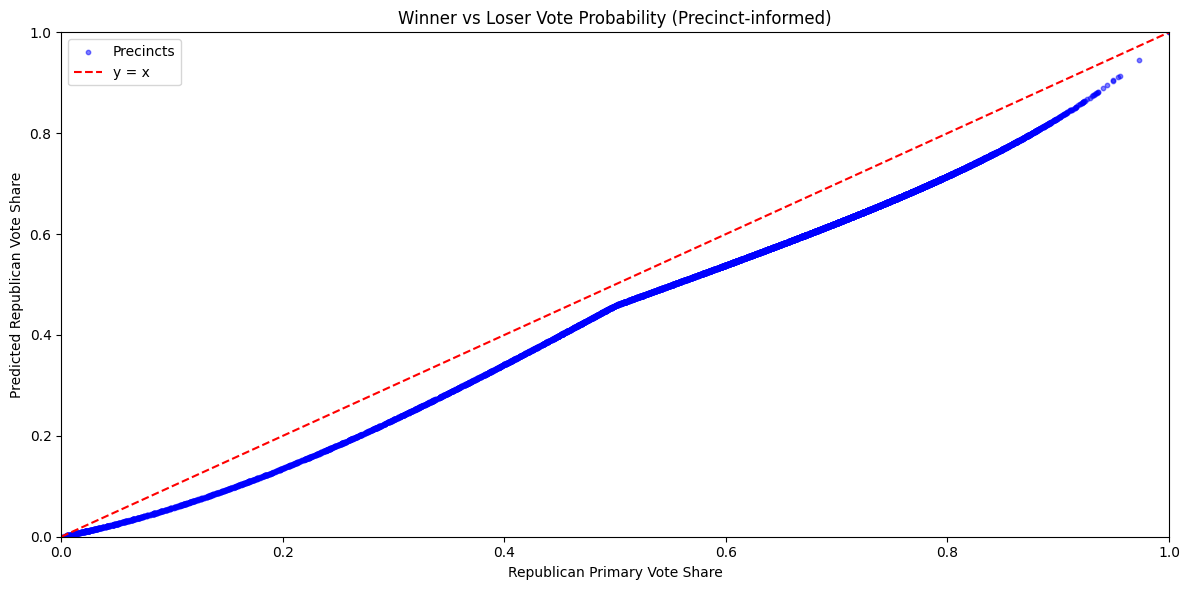

In [22]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=OH_data['primary_rep_voteshare'], 
    y=OH_data['predicted_rep_share_state'], 
    color='blue', label='Precincts', alpha=0.5, s=10
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x')
plt.title("Winner vs Loser Vote Probability (Precinct-informed)")
plt.xlabel('Republican Primary Vote Share')
plt.ylabel('Predicted Republican Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()



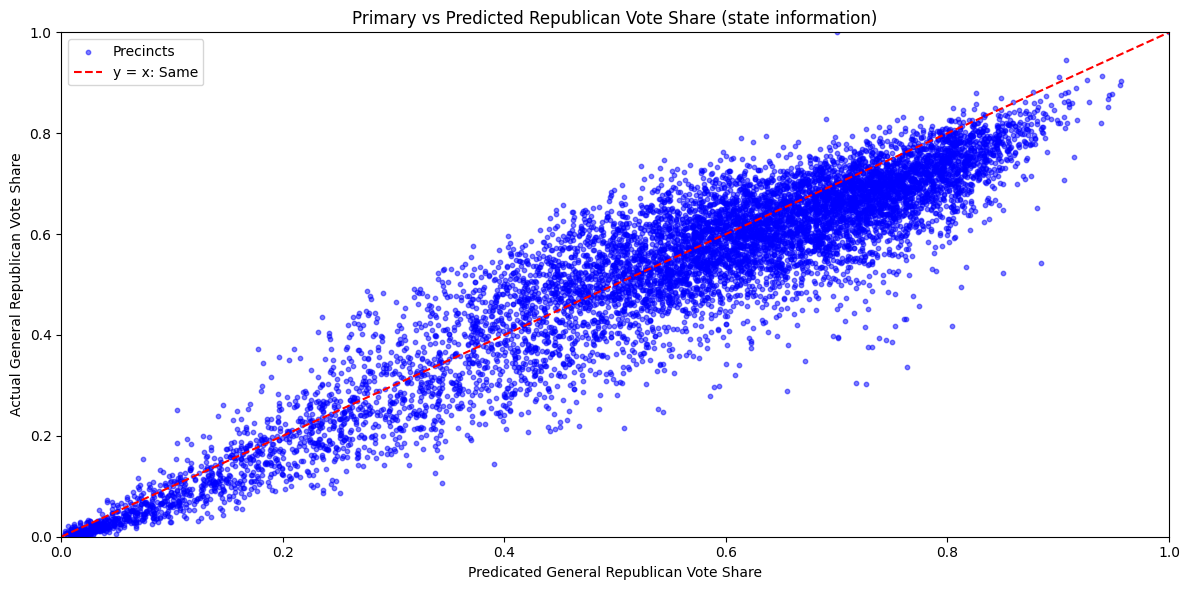

In [23]:
plt.figure(figsize=(12, 6))
plt.scatter(
    x=OH_data['actual_general_rep_share'], 
    y=OH_data['predicted_rep_share_state'], 
    color='blue', label='Precincts', alpha=0.5, s=10
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Same')
plt.title('Primary vs Predicted Republican Vote Share (state information)')
plt.xlabel('Predicated General Republican Vote Share')
plt.ylabel('Actual General Republican Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## Plotting these 2 effects

In [24]:
OH_data

,Unnamed: 0,...1,precinct,gen_rep_TRUMP,gen_dem_CLINTON,gen_rep_JOHNSON,gen_dem_STEIN,pri_dem_CLINTON,pri_dem_LA.FUENTE,pri_dem_SANDERS,...,primary_winner,predicted_dem_gen,predicted_rep_gen,actual_general_rep_share,predicted_rep_share,primary_rep_voteshare,state_primary_winner,predicted_dem_gen_state,predicted_rep_gen_state,predicted_rep_share_state
0,0,1,ADAMSAAA,532.0,96.0,12.0,4.0,27.0,1.0,26.0,...,rep,22.827367,401.397991,0.844720,0.946190,0.858639,rep,74.199018,260.947459,0.778607
1,1,2,ADAMSAAB,390.0,95.0,9.0,0.0,36.0,0.0,28.0,...,rep,39.715169,304.933152,0.807692,0.884766,0.792208,rep,86.722241,209.410174,0.707150
2,2,3,ADAMSAAD,408.0,94.0,5.0,4.0,39.0,0.0,34.0,...,rep,43.159859,322.651099,0.808219,0.882016,0.789625,rep,93.084117,222.010757,0.704584
3,3,4,ADAMSAAE,176.0,76.0,2.0,1.0,35.0,0.0,22.0,...,rep,78.926183,133.166760,0.698039,0.627870,0.592857,rep,90.611359,103.285584,0.532683
4,4,5,ADAMSAAG,258.0,73.0,8.0,2.0,22.0,1.0,21.0,...,rep,28.283177,208.929522,0.780059,0.880769,0.788462,rep,60.663081,143.886811,0.703431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8884,8884,8885,WYANDOTABH,221.0,45.0,13.0,3.0,17.0,1.0,8.0,...,rep,12.950473,173.356327,0.829787,0.930488,0.839506,rep,36.828396,114.603935,0.756800
8885,8885,8886,WYANDOTABI,368.0,103.0,19.0,2.0,38.0,1.0,18.0,...,rep,42.987370,289.038960,0.786585,0.870530,0.779070,rep,88.289977,200.450712,0.694224
8886,8886,8887,WYANDOTABJ,293.0,100.0,13.0,3.0,31.0,1.0,28.0,...,rep,56.907912,234.130764,0.748166,0.804466,0.723502,rep,93.834474,168.705002,0.642589
8887,8887,8888,WYANDOTABL,241.0,55.0,12.0,1.0,20.0,1.0,15.0,...,rep,21.236400,190.049403,0.818770,0.899490,0.806452,rep,49.815463,129.088014,0.721551


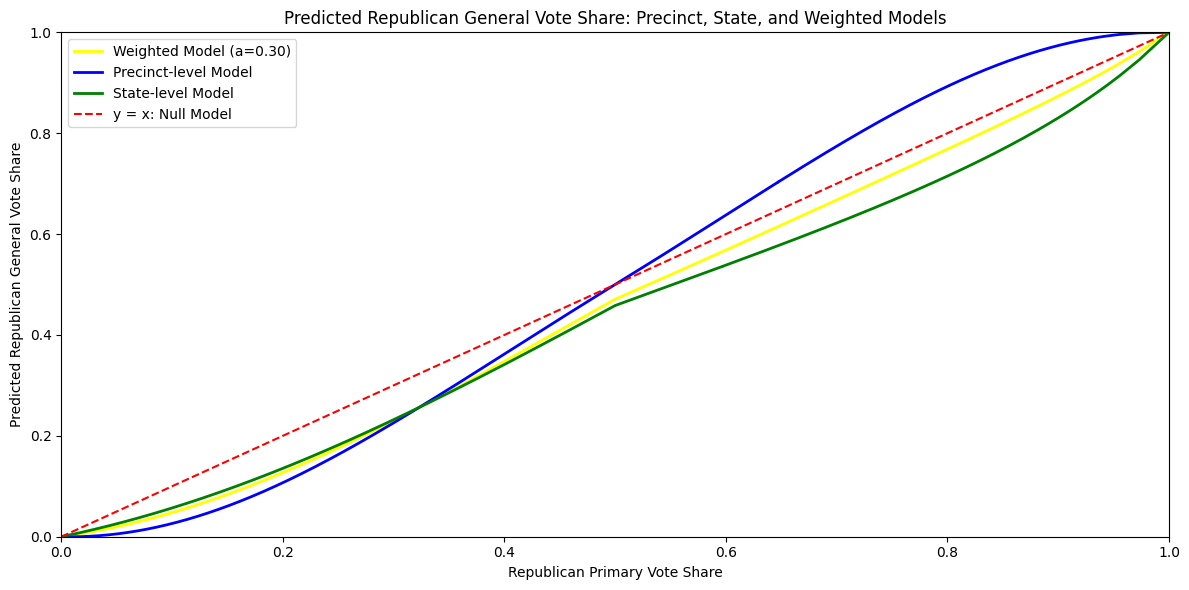

In [25]:
# Create a weighted model: a * precinct + (1 - a) * state
a = 0.3  

OH_data['predicted_rep_share_weighted'] = (
    a * OH_data['predicted_rep_share'] +
    (1 - a) * OH_data['predicted_rep_share_state']
)

# Sort for smooth plotting
sorted_weighted = OH_data.sort_values('primary_rep_voteshare')

plt.figure(figsize=(12, 6))
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_weighted'],
    color='yellow', linewidth=2, label=f'Weighted Model (a={a:.2f})'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share'],
    color='blue', linewidth=2, label='Precinct-level Model'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_state'],
    color='green', linewidth=2, label='State-level Model'
)

plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='y = x: Null Model')
plt.title('Predicted Republican General Vote Share: Precinct, State, and Weighted Models')
plt.xlabel('Republican Primary Vote Share')
plt.ylabel('Predicted Republican General Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

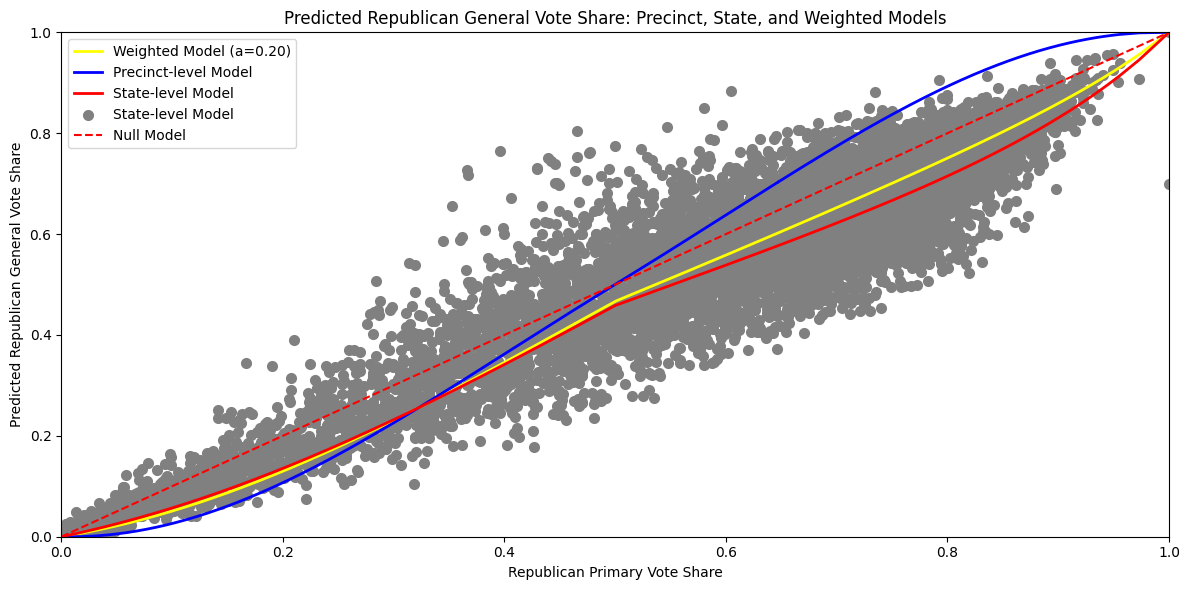

In [26]:
# Create a weighted model: a * precinct + (1 - a) * state
a = 0.2  

OH_data['predicted_rep_share_weighted'] = (
    a * OH_data['predicted_rep_share'] +
    (1 - a) * OH_data['predicted_rep_share_state']
)

# Sort for smooth plotting
sorted_weighted = OH_data.sort_values('primary_rep_voteshare')

plt.figure(figsize=(12, 6))
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_weighted'],
    color='yellow', linewidth=2, label=f'Weighted Model (a={a:.2f})'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share'],
    color='blue', linewidth=2, label='Precinct-level Model'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_state'],
    color='red', linewidth=2, label='State-level Model'
)
plt.scatter(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['actual_general_rep_share'],
    color='gray', linewidth=2, label='State-level Model'
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Null Model')
plt.title('Predicted Republican General Vote Share: Precinct, State, and Weighted Models')
plt.xlabel('Republican Primary Vote Share')
plt.ylabel('Predicted Republican General Vote Share')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

(0.0, 1.0)

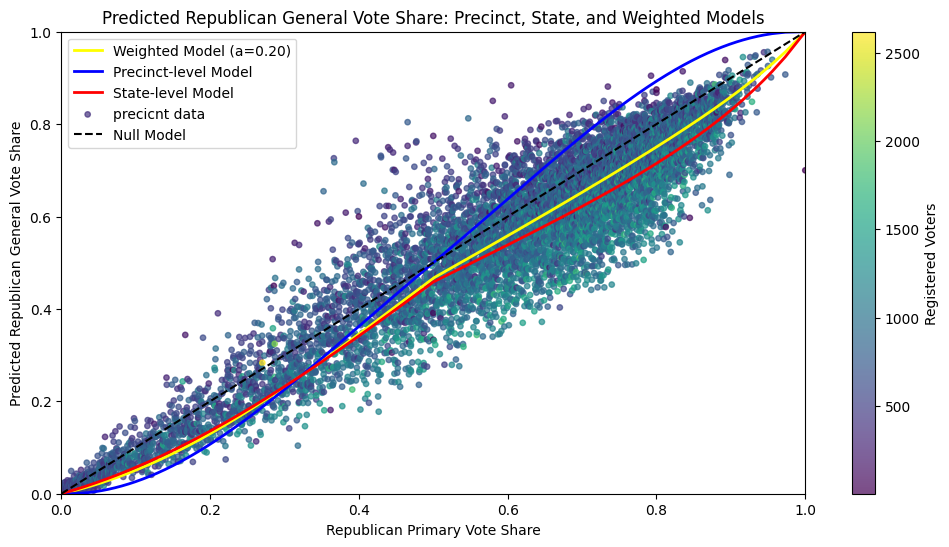

In [27]:
# Create a weighted model: a * precinct + (1 - a) * state
a = 0.2  

OH_data['predicted_rep_share_weighted'] = (
    a * OH_data['predicted_rep_share'] +
    (1 - a) * OH_data['predicted_rep_share_state']
)

# Sort for smooth plotting
sorted_weighted = OH_data.sort_values('primary_rep_voteshare')

plt.figure(figsize=(12, 6))
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_weighted'],
    color='yellow', linewidth=2, label=f'Weighted Model (a={a:.2f})'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share'],
    color='blue', linewidth=2, label='Precinct-level Model'
)
plt.plot(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['predicted_rep_share_state'],
    color='red', linewidth=2, label='State-level Model'
)

# Scatter actual values, color by precinct_size
sc = plt.scatter(
    sorted_weighted['primary_rep_voteshare'],
    sorted_weighted['actual_general_rep_share'],
    c=sorted_weighted['precinct_size'],
    cmap='viridis',
    alpha=0.7,
    s=15,
    label='precicnt data'
)
plt.colorbar(sc, label='Registered Voters')

plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Null Model')
plt.title('Predicted Republican General Vote Share: Precinct, State, and Weighted Models')
plt.xlabel('Republican Primary Vote Share')
plt.ylabel('Predicted Republican General Vote Share')
plt.legend()
plt.xlim(0, 1)
plt.ylim(0, 1)